# Task 2A - 03 Feature engineering (evidence first)
Every feature is justified by an effect we can *see* in the history, and every one is known in advance from `calendar.csv`.

In [1]:
import sys, warnings; warnings.filterwarnings('ignore')
sys.path.append('../../tools/task2a')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib, json
from task2a_common import *
from task2a_features import *
from task2a_models import *
from task2a_validation import *
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 50); pd.set_option('display.max_rows', 100)
plt.rcParams.update({'figure.dpi': 90, 'axes.grid': True, 'grid.alpha': .25})
for d in (INTERIM, METRICS, FIGURES): d.mkdir(parents=True, exist_ok=True)
o, cal = load_orders(); cal2 = enrich_calendar(cal); panel = build_panel(o, cal2)


## 1. Order size is the moving part: festival run-up, by festival

In [2]:
f = panel[(panel.brand == 'Fresh') & (panel.depot == 'Peliyagoda')].copy()
f['rb'] = pd.cut(f.festival_ramp, [-.01, 0, .3, .6, .8, 1.0])
base = f[f.festival_ramp == 0].vol.mean()
rows = []
for t in FEST_TYPES:
    g = f[(f.nf == t) & (f.festival_ramp > 0.3)]
    rows.append((t, g.date.dt.year.nunique(), len(g), g.vol.mean() / base - 1, g[g.festival_ramp > .7].vol.mean() / base - 1))
r = pd.DataFrame(rows, columns=['festival', 'years_seen', 'run_up_days', 'uplift_ramp>0.3', 'uplift_ramp>0.7']).round(3)
print('baseline (ramp=0) mean daily volume: %.1f m3' % base); r

baseline (ramp=0) mean daily volume: 156.4 m3


,festival,years_seen,run_up_days,uplift_ramp>0.3,uplift_ramp>0.7
0,new_year,2,10,0.461,0.696
1,vesak,2,12,0.177,0.255
2,poson,2,12,0.089,0.107
3,esala,2,12,0.158,0.206
4,deepavali,2,12,0.282,0.340
5,christmas,2,10,0.379,0.398
6,thai_pongal,3,18,0.103,0.146


**Finding.** Festivals are **not** equal: the Sinhala New Year run-up lifts Fresh daily volume far more than Vesak, Poson or Esala. One shared `festival_ramp` coefficient averages them and under-forecasts the New Year (the biggest event in our window). Hence one ramp column **per festival** (`r_new_year`, `r_vesak`, ...); the ridge penalty keeps the rarely-seen ones stable.

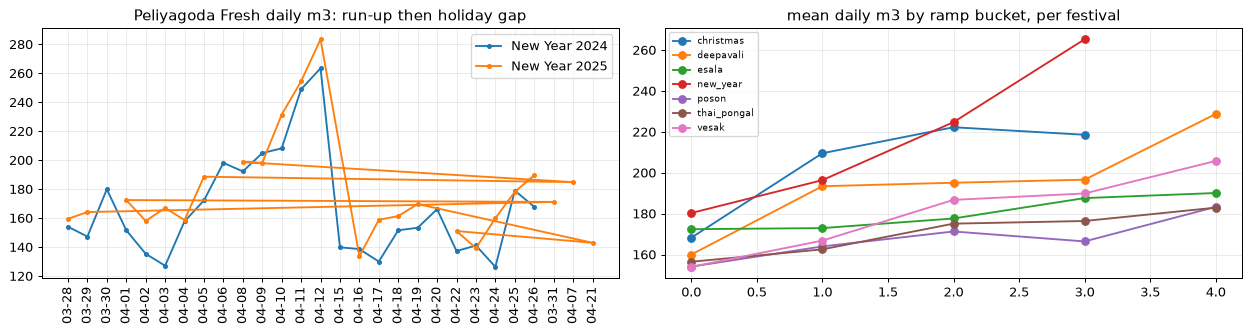

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(14, 3.8))
for yr, col in [(2024, 'C0'), (2025, 'C1')]:
    g = f[(f.date >= f'{yr}-03-28') & (f.date <= f'{yr}-04-26')]
    axs[0].plot(g.date.dt.strftime('%m-%d'), g.vol, marker='o', ms=3, label=f'New Year {yr}', color=col)
axs[0].legend(); axs[0].tick_params(axis='x', rotation=90); axs[0].set_title('Peliyagoda Fresh daily m3: run-up then holiday gap')
for t, g in f[f.festival_ramp > 0.05].groupby('nf'):
    m = g.groupby(pd.cut(g.festival_ramp, [0, .3, .5, .7, .9, 1.0])).vol.mean()
    axs[1].plot(range(len(m)), m.values, marker='o', label=t)
axs[1].legend(fontsize=7); axs[1].set_title('mean daily m3 by ramp bucket, per festival')
plt.tight_layout(); plt.savefig(FIGURES / '03_festival_effects.png'); plt.show()

## 2. Weekday, payday, trend, monsoon

In [4]:
g = panel[panel.brand == 'Fresh']
print('daily m3 by weekday (Mon..Sat):'); print(g.groupby(['depot', 'dow']).vol.mean().unstack().round(0))
print('\npayday uplift (payday / non-payday mean daily volume):'); print((g.groupby(['depot', 'is_payday']).vol.mean().unstack().pipe(lambda d: d[1] / d[0])).round(3))
print('\nmonsoon uplift:'); print((g.groupby(['depot', 'monsoon']).vol.mean().unstack().pipe(lambda d: d[1] / d[0])).round(3))
yr = g[g.festival_ramp == 0].groupby(['depot', g.date.dt.year]).vol.mean().unstack(); print('\nmean daily m3 outside run-ups by year:'); print(yr.round(1)); print('growth 2025->2026:', (yr[2026] / yr[2025] - 1).round(3).to_dict())

daily m3 by weekday (Mon..Sat):
dow             0      1      2      3      4      5
depot                                               
Kandy        79.0   75.0   81.0   84.0   93.0   94.0
Peliyagoda  155.0  153.0  143.0  168.0  167.0  180.0

payday uplift (payday / non-payday mean daily volume):
depot
Kandy         1.116
Peliyagoda    1.123
dtype: float64

monsoon uplift:
depot
Kandy         1.003
Peliyagoda    1.001
dtype: float64

mean daily m3 outside run-ups by year:
date         2024   2025   2026
depot                          
Kandy        78.4   83.6   87.3
Peliyagoda  150.9  159.4  165.7
growth 2025->2026: {'Kandy': 0.045, 'Peliyagoda': 0.039}


**Findings.** Fri/Sat orders are larger; paydays add about 10-12%; monsoon has **no** demand effect (so it is not a feature); there is steady growth of a few % per year for Fresh, handled with a **damped trend**; trend options (none / full / damped) are compared per brand in 05c.

## 3. Is there catch-up demand after a non-operating day?

In [5]:
gg = panel[(panel.brand == 'Fresh') & (panel.depot == 'Peliyagoda')].copy()
gg['prev_gap'] = (gg.date - gg.date.shift(1)).dt.days
after = gg[(gg.prev_gap > 1) & (gg.date.dt.dayofweek != 0)]          # day after a non-Sunday gap
norm = gg[(gg.prev_gap == 1)]
print('days directly after a holiday gap:', len(after), '| mean vol %.1f vs %.1f on ordinary days' % (after.vol.mean(), norm.vol.mean()))
print('orders/day after gap %.1f vs %.1f' % (after.n_orders.mean(), norm.n_orders.mean()))

days directly after a holiday gap: 5 | mean vol 170.5 vs 162.1 on ordinary days
orders/day after gap 80.2 vs 82.2


**Finding.** The day after a holiday gap looks like any other day (same order counts and sizes). Closed days are *lost* demand, not postponed, so weekly totals shrink proportionally in short weeks and no catch-up feature is needed.

## 4. Tech: a weekday schedule plus noise

In [6]:
t = panel[panel.brand == 'Tech']
print('Tech mean daily m3 by weekday:'); print(t.groupby(['depot', 'dow']).vol.mean().unstack().round(1))
print('\nshare of operating days with zero Tech volume:', (t.vol == 0).groupby(t.depot).mean().round(2).to_dict())
print('payday uplift:', (t.groupby(['depot', 'is_payday']).vol.mean().unstack().pipe(lambda d: d[1] / d[0])).round(2).to_dict())

Tech mean daily m3 by weekday:
dow           0    1    2    3     4    5
depot                                    
Kandy       1.1  0.0  9.8  5.2   4.0  1.4
Peliyagoda  0.9  8.2  1.6  0.0  12.3  6.9

share of operating days with zero Tech volume: {'Kandy': 0.42, 'Peliyagoda': 0.32}
payday uplift: {'Kandy': 1.2, 'Peliyagoda': 1.31}


## Final feature set
| Group | Features | Used by |
|---|---|---|
| Weekday | `d0..d5` (Sunday never operates) | all |
| Cash cycle | `is_payday` | all |
| Festivals | `festival_ramp`, `festival_ramp^2`, `is_holiday`, one `r_<festival>` ramp per festival | Fresh, Style; Tech uses ramp only |
| Trend | years since 2024-01-01: damped (phi 0.9 per week) for Fresh and Tech, **none** for Style (chosen in 05c) | Fresh, Tech |
| Residual learner inputs | weekday, ISO week, days to next / since last festival, ramp, payday | boosting on ridge residuals |
| Depot | depot x weekday intercepts, depot trend (pooled model) | Fresh, Style |

Deliberately **not** used: monsoon (no effect), lagged demand (not known 10 weeks ahead), outlet counts (fixed).
Calendar features are saved in `data/processed` terms by `enrich_calendar`; the feature list is also written to `reports/metrics/task2a/task2a_feature_meta.json`.

In [7]:
meta = {'base_cols': BASE_COLS, 'festival_ramp_cols': RAMP_COLS, 'gb_cols': GB_COLS, 'trend': 'damped phi=0.9/week', 'targets': ['vol', 'ch']}
json.dump(meta, open(METRICS / 'task2a_feature_meta.json', 'w'), indent=1); meta

{'base_cols': ['d0',
  'd1',
  'd2',
  'd3',
  'd4',
  'd5',
  'is_payday',
  'festival_ramp',
  'is_holiday'],
 'festival_ramp_cols': ['r_new_year',
  'r_vesak',
  'r_poson',
  'r_esala',
  'r_deepavali',
  'r_christmas',
  'r_thai_pongal'],
 'gb_cols': ['dow', 'iso_week', 'dtn', 'dsl', 'festival_ramp', 'is_payday'],
 'trend': 'damped phi=0.9/week',
 'targets': ['vol', 'ch']}